<a href="https://colab.research.google.com/github/mojordan235-oss/Project/blob/main/Copy_of_Meaching_Learning_MidtermProject_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Midterm Project Part 1
# Analyzing the Demand for Bike Sharing

Bike sharing systems are a means of renting bicycles where the process of obtaining membership, rental, and bike return is automated via a network of kiosk locations throughout a city. Using these systems, people are able rent a bike from a one location and return it to a different place on an as-needed basis. Currently, there are over 500 bike-sharing programs around the world.

For this project, we will explore a dataset from Capital Bikeshare, a bike-sharing program in Washington, D.C. It is interesting to discover bike usage patterns with weather condition and the nature of the day.

# I. Acquire the Dataset

1. Download the data `Bike-Sharing-Dataset.zip` file from [Bike Sharing dataset in the Machine Learning Repository at UC Irvine](https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset). Unzip the file and obtain file `day.csv`. Read the description of the dataset to learn the meaning of values in each column.

2. Load the data from `day.csv` as a Pandas data frame. Display its first 5 rows to confirm that the data is loaded correctly.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
data=pd.read_csv("day.csv")
data.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


3. Display the shape of the data frame.

In [ ]:
data.shape


(731, 16)

4. Display the data type of each column

In [ ]:
print(data.dtypes)

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


5. The default data type for 'dteday' is `object`. Use [pd.to_datetime](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) to convert it to `datetime` type. After the conversion, display the data types again to confirm that the conversion is successful.

In [ ]:
data["dteday"]=pd.to_datetime(data["dteday"])
print(data.dtypes)

instant                int64
dteday        datetime64[ns]
season                 int64
yr                     int64
mnth                   int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object


6. Create a new column 'year' by extracting the year value from the datetime of each row.

In [ ]:
data['year']= data['yr']
data

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt,year
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.805833,0.160446,985,0
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.696087,0.248539,801,0
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.437273,0.248309,1349,0
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.590435,0.160296,1562,0
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.436957,0.186900,1600,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,2012-12-27,1,1,12,0,4,1,2,0.254167,0.652917,0.350133,2114,1
727,2012-12-28,1,1,12,0,5,1,2,0.253333,0.590000,0.155471,3095,1
728,2012-12-29,1,1,12,0,6,0,2,0.253333,0.752917,0.124383,1341,1
729,2012-12-30,1,1,12,0,0,0,1,0.255833,0.483333,0.350754,1796,1


7. Remove the "casual" column and the "registered" column, as we are solely interested in the total number of bike rentals, which is given in the "cnt" column. Also remove the following columns: 'instant', 'yr', 'atemp'. Display the first 5 rows again to confirm the removal of these columns.

8. Display the number of missing values from each column.

In [ ]:
data.isnull().sum


<bound method DataFrame.sum of      dteday  season     yr   mnth  holiday  weekday  workingday  weathersit  \
0     False   False  False  False    False    False       False       False   
1     False   False  False  False    False    False       False       False   
2     False   False  False  False    False    False       False       False   
3     False   False  False  False    False    False       False       False   
4     False   False  False  False    False    False       False       False   
..      ...     ...    ...    ...      ...      ...         ...         ...   
726   False   False  False  False    False    False       False       False   
727   False   False  False  False    False    False       False       False   
728   False   False  False  False    False    False       False       False   
729   False   False  False  False    False    False       False       False   
730   False   False  False  False    False    False       False       False   

      temp    hum  windspeed    cnt   year  
0    False  False      False  False  False  
1    False  False      False  False  False  
2    False  False      False  False  False  
3    False  False      False  False  False  
4    False  False      False  False  False  
..     ...    ...        ...    ...    ...  
726  False  False      False  False  False  
727  False  False      False  False  False  
728  False  False      False  False  False  
729  False  False      False  False  False  
730  False  False      False  False  False  

[731 rows x 13 columns]>

## II. Data Exploration

In [ ]:
data=data.drop(columns=['casual','registered','instant','yearr','atemp'], errors='ignore')
data.head()



,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt,year
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.805833,0.160446,985,0
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.696087,0.248539,801,0
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.437273,0.248309,1349,0
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.590435,0.160296,1562,0
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.436957,0.186900,1600,0


1. The season feature: split the data frame into four subsets according to the season value. You may call them `data_spring`, `data_summer`, `data_fall`, `data_winter`. Calculate and display the average bike rentals in each season.

In [ ]:
data_spring= data[data['season']==1]
data_summer= data[data['season']==2]
data_fall= data[data['season']==3]
data_winter= data[data['season']==4]

display(data_spring['cnt'].mean())
display(data_summer['cnt'].mean())
display(data_fall['cnt'].mean())
display(data_winter['cnt'].mean())

np.float64(2604.1325966850827)

np.float64(4992.33152173913)

np.float64(5644.303191489362)

np.float64(4728.162921348315)

2. The 'holiday' feature: calculate and display the average bike rentals for holidays and non-holidays, separately.

In [ ]:
holiday=data[data['holiday']==1]
nonholiday=data[data['holiday']==0]

display(holiday['cnt'].mean())
display(nonholiday['cnt'].mean())

np.float64(3735.0)

np.float64(4527.104225352113)

3. The 'workingday' feature: calculate and display the average bike rentals for working days and weekends, separately.

In [ ]:
workingday=data[data['workingday']==1]
weekends=data[data['workingday']==0]

display(workingday['cnt'].mean())
display(weekends['cnt'].mean())

np.float64(4584.82)

np.float64(4330.168831168831)

4. The 'weathersit' feature: calculate and display the average bike-rentals for each weather type.

In [ ]:
weathersitone=data[data['weathersit']==1]
weathersittwo=data[data['weathersit']==2]

display(weathersitone['cnt'].mean())
display(weathersittwo['cnt'].mean())

np.float64(4876.7861771058315)

np.float64(4035.862348178138)

5. The 'temp' feature: as temperature is a countinous feature, its relationship with the 'count' feature can be visualized as a scatter plot. Create a scatter plot with 'temp' and 'count'. Label the axis correctly.

Text(0.5, 1.0, 'Temp vs Count')

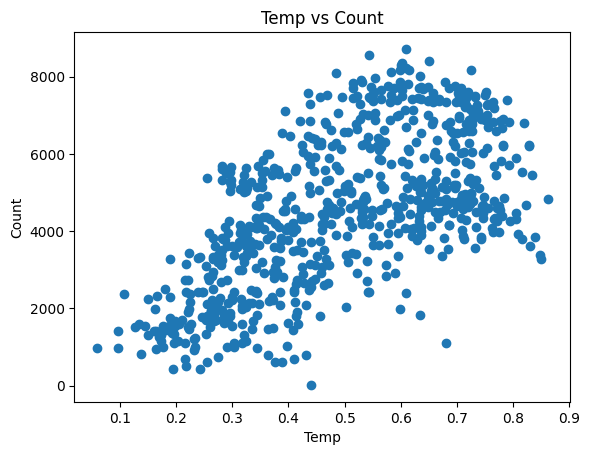

In [ ]:
plt.scatter(data["temp"],data["cnt"])

plt.xlabel("Temp")
plt.ylabel("Count")
plt.title("Temp vs Count")

6. The 'windspeed' feature: create a scatter plot to show the relatioinship between the number of bike rentals and the windspeed.

Text(0.5, 1.0, 'Windspeed vs Count')

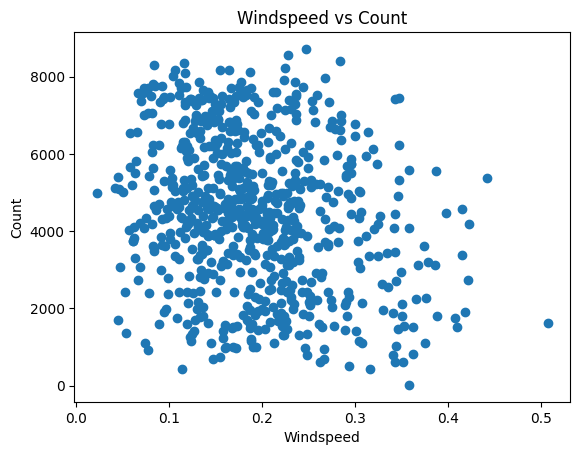

In [ ]:
plt.scatter(data["windspeed"],data["cnt"])

plt.xlabel("Windspeed")
plt.ylabel("Count")
plt.title("Windspeed vs Count")

7. The 'year' feature: calculate and display the average bike rentals in each year.

In [ ]:
year0=data[data['yr']==0]
year1=data[data['yr']==1]

display(year0['cnt'].mean())
display(year1['cnt'].mean())

np.float64(3405.7616438356163)

np.float64(5599.934426229508)

8. What observations can you conclude from the data exploration?

In [ ]:
"When I was doing the scatterplot in the Temp vs Count and Windspeed vs Count the Temp vs Count scatterplot was spread out more than Windspeed vs Count scatterplot "

'When I was doing the scatterplot in the Temp vs Count and Windspeed vs Count the Temp vs Count scatterplot was spread out more than Windspeed vs Count scatterplot '

**Answer:**



9. Save the final data frame as a csv file using the `to_csv()` method. Read the [documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) of this method for more information.

In [ ]:
data.to_csv("MidtermProjectPart1.csv", index=False)